# **Assingment 2.2.:** Advanced Topics 

## **Task 1:** Dimensionality Reduction

**Importing libraries:**

In [4]:
!where python
%run ../helper.py

# for PCA
from sklearn.decomposition import PCA

# for standardizing data
from sklearn.preprocessing import StandardScaler

# for MDS
from sklearn.manifold import MDS

# for t-SNE
from sklearn.manifold import TSNE

# for Task 2, networks
import networkx as nx

C:\Users\Lauri\OneDrive - Aalto University\Tiedostot\Koulujuttuja\2026 Information Visualization\infoviz\.venv\Scripts\python.exe
C:\Users\Lauri\AppData\Local\Programs\Python\Python310\python.exe
C:\Users\Lauri\AppData\Local\Microsoft\WindowsApps\python.exe


PCA, MDS & t-SNE to perform dimensionality reduction and to present multidimensional data in two dimensions

First task requires 10 vizualizations in total, 2 for PCA, 2 for MDS and 6 for t-SNE

Importing the required data (same as before):

In [5]:
# UNIDO data, 2010-2023
df = pd.read_csv("../data/data1.csv")

**Dimensionality reduction mostly done on
cross section of data. Analysis will be done with the year 2023.**

Variables chosen for dimensionality reduction:
- Manufacturing value added per capita
- Manufactured exports per capita
- Manufactured exports share in total exports
- Manufacturing value added share in total GDP
- Medium- and high-tech MVA share in total MVA
- Medium- and high-tech manufactured exports share in total manufactured exports

The first two variables are in dollar terms, while the last four are in shares that can range from 0 to 1. 

Original data is in long format. It needs to be transformed to wide format (variables in columns) to perform dimensionality reduction:

In [6]:
# Variables for dimensionality reduction (6 raw CIP components)
# plus CIP score itself for coloring/annotation
# Drop everyhting else
keep_vars = ['MVApc', 'MVAsh', 'MXpc', 'MXsh', 'MHVAsh', 'MHXsh', 'cip']
 
# Filter to year 2023 and selected variables
df_2023 = df[(df['Year'] == 2023) & (df['VariableCode'].isin(keep_vars))]
 
# Pivot from long to wide: one row per country, variables as columns
df_wide = df_2023.pivot(index='Country', columns='VariableCode', values='Value')
 
# Reorder columns: 6 analysis variables first, then CIP score for reference
df_wide = df_wide[['MVApc', 'MVAsh', 'MXpc', 'MXsh', 'MHVAsh', 'MHXsh', 'cip']]
df_wide = df_wide.reset_index()
 
# Result: 153 rows (countries) x 8 columns (Country + 6 variables + CIP score)
df_wide

VariableCode,Country,MVApc,MVAsh,MXpc,MXsh,MHVAsh,MHXsh,cip
0,Afghanistan,29.095224,0.073170,1.329986,0.058285,0.084650,0.003410,0.000815
1,Albania,324.561675,0.061608,997.570780,0.641124,0.074868,0.186143,0.011370
2,Algeria,466.856504,0.100818,276.334956,0.327361,0.026933,0.039488,0.019832
3,Angola,208.530340,0.069548,27.056337,0.026665,0.039675,0.233716,0.005744
4,Argentina,1901.313066,0.135577,490.593036,0.334501,0.288348,0.444910,0.048994
...,...,...,...,...,...,...,...,...
148,Venezuela (Bolivarian Republic of),54.549469,0.013915,432.415577,0.147048,0.342825,0.096520,0.009239
149,Viet Nam,943.646552,0.250943,3118.101430,0.886231,0.385406,0.594966,0.112414
150,Yemen,43.036102,0.089655,0.232644,0.963777,0.020650,0.002451,0.000000
151,Zambia,106.566099,0.081147,96.414502,0.203645,0.097255,0.328582,0.006808


### **First,** PCA without standardization:

**PCA dataframe creation:**

In [7]:
# Separate analysis variables from CIP
analysis_vars = ['MVApc', 'MVAsh', 'MXpc', 'MXsh', 'MHVAsh', 'MHXsh'] 
X = df_wide[analysis_vars].values #creating a matrix with the values of the variables that PCA is performed on (pulled from df_wide)
cip_scores = df_wide['cip'].values #extracting CIP values in case of further use
countries = df_wide['Country'].values #fetching the country names

# PCA, non-standardized data
pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

# Creating the data frame following PCA. Each country is a row, first and second row are named as below
df_pca = pd.DataFrame(X_r, columns=["First Principal Component", "Second Principal Component"])
df_pca["CIP Score"] = cip_scores #adds CIP score as a third variable to the dataframe
df_pca["Country"] = countries #country names added as fourth column
#df_pca

**Plotting the PCA results:**

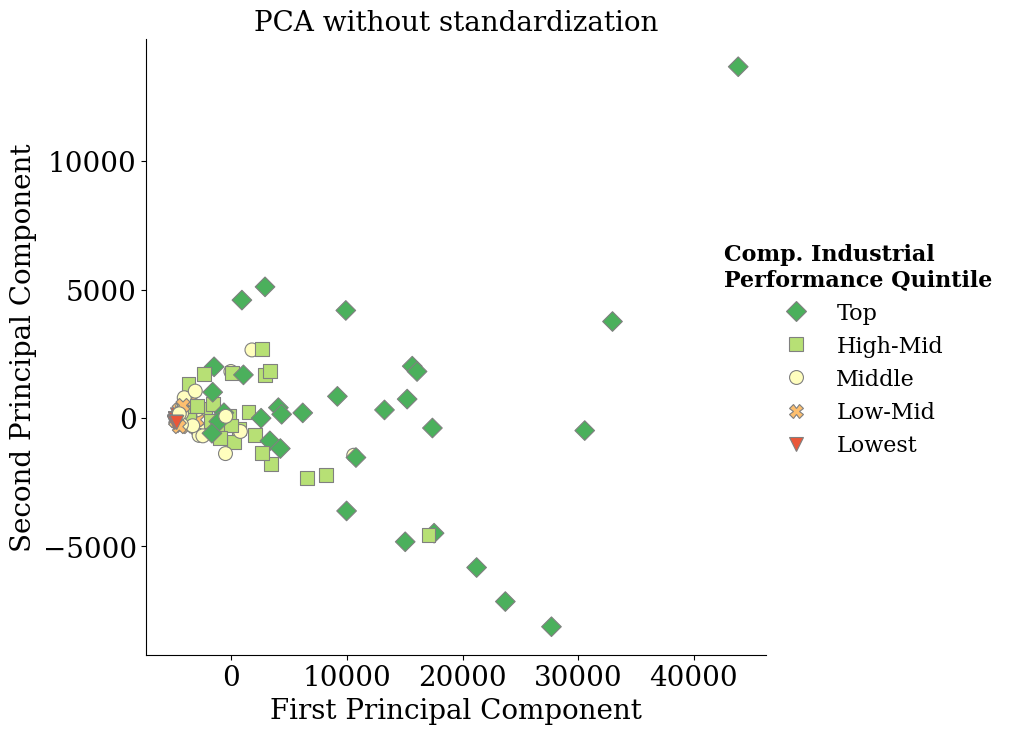

In [8]:
# Create quintiles accroding to CIP values
df_pca["CIP Group"] = pd.qcut(df_pca["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Creating plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(df_pca,
                x="First Principal Component", #label x axis
                y="Second Principal Component", #label y axis
                hue="CIP Group", #color hue according to CIP group (red-yellow-green)
                style="CIP Group", #assign the markers to the data points
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r", #color palette, reversed
                s=100, #datapoint size
                edgecolor="gray", #datapoint border
                linewidth=0.8) #datapoint border width

# Move legend to the right, outside the plot area, control positioning
ax.legend(bbox_to_anchor=(0.9, 0.7), #manual legend positioning
          loc='upper left',
          fontsize=16, #font size of group names
          title="Comp. Industrial\nPerformance Quintile",
          title_fontproperties={'weight': 'bold', 'size': 16}) #title styling

# Axis modifications and saving image
plt.title('PCA without standardization')
sns.despine(fig)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
plt.savefig("../figures/pca_without_standardization.png", dpi=300, bbox_inches='tight')
plt.show()

**PCA decomposition. How much each variable explains the variance in the PCA:**

In [9]:
# Print variable names, explained variance and loadings
var_names = {
    'MVApc': 'Manufacturing value added per capita',
    'MVAsh': 'Manufacturing value added share in total GDP',
    'MXpc': 'Manufactured exports per capita',
    'MXsh': 'Manufactured exports share in total exports',
    'MHVAsh': 'Medium- and high-tech MVA share in total MVA',
    'MHXsh': 'Medium- and high-tech manufactured exports share in total manufactured exports'
}

print("Variables:")
for code, name in var_names.items():
    print(f"  {code} = {name}")
print()

print("Explained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.1%}\n")

print("Loadings:")
loading_df = pd.DataFrame(
    pca.components_.round(4),
    columns=analysis_vars,
    index=["PC1", "PC2"]
)
print(loading_df.to_string())

Variables:
  MVApc = Manufacturing value added per capita
  MVAsh = Manufacturing value added share in total GDP
  MXpc = Manufactured exports per capita
  MXsh = Manufactured exports share in total exports
  MHVAsh = Medium- and high-tech MVA share in total MVA
  MHXsh = Medium- and high-tech manufactured exports share in total manufactured exports

Explained variance:
  PC1: 94.7%
  PC2: 5.3%
  Total: 100.0%

Loadings:
      MVApc  MVAsh    MXpc  MXsh  MHVAsh  MHXsh
PC1  0.3993    0.0  0.9168   0.0     0.0    0.0
PC2  0.9168    0.0 -0.3993  -0.0     0.0    0.0


We see that all the variance in the PCA without standardization is caused by the variables in absolute values. This is expected, as their values have variation that ranges from 0 to tens of thousands (dollars) and shares are capped at 1. 

### **Next, PCA with standardized variables:**

The only thing that is different in this case, is that all the variables are **transformed to have mean 0 and standard deviation 1**. Everything else remains the same. Evidently, the analysis changes, as now all the 6 variables are comparable. 

In [10]:
# Standardize the data: mean=0, std=1 for each variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Run PCA on standardized data
pca_std = PCA(n_components=2)
X_r_std = pca_std.fit(X_scaled).transform(X_scaled)

# Build DataFrame for plotting
df_pca_std = pd.DataFrame(X_r_std, columns=["First Principal Component", "Second Principal Component"])
df_pca_std["CIP Score"] = cip_scores
df_pca_std["Country"] = countries

**Plotting created PCA dataframe:**

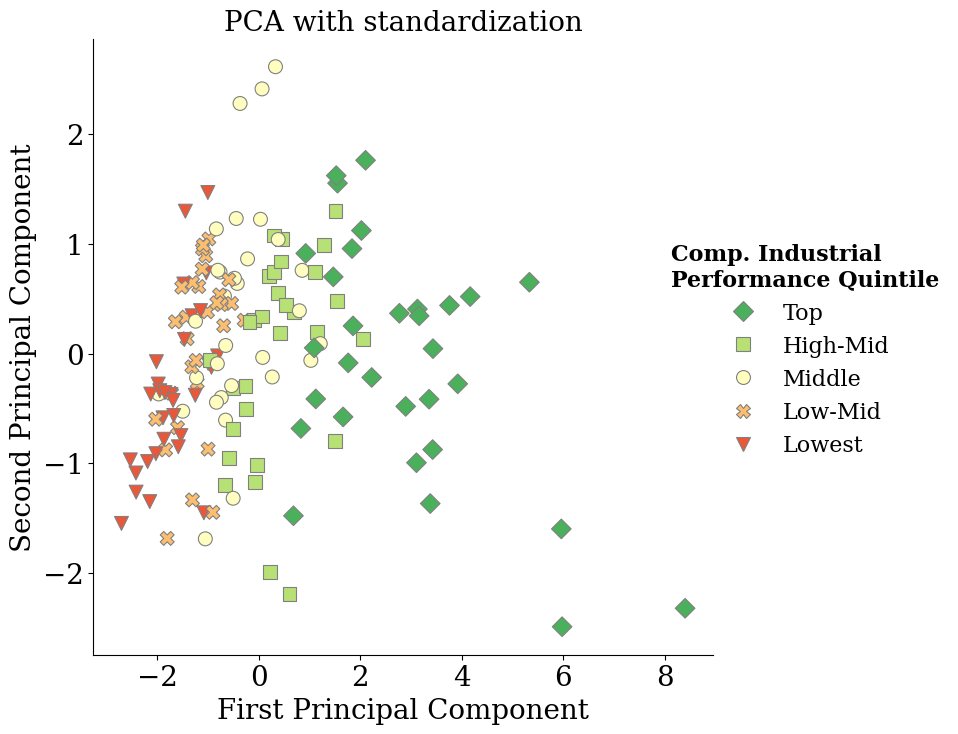

In [12]:
# Plot PCA with standardized variables
# Create quintiles accroding to CIP values
df_pca_std["CIP Group"] = pd.qcut(df_pca_std["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(df_pca_std,
                x="First Principal Component",
                y="Second Principal Component",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=100,
                edgecolor="gray",
                linewidth=0.8)

ax.legend(bbox_to_anchor=(0.9, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Quintile",
          title_fontproperties={'weight': 'bold', 'size': 16})

plt.title('PCA with standardization')
sns.despine(fig)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
plt.savefig("../figures/pca_with_standardization.png", dpi=300, bbox_inches='tight')
plt.show()

**Printing the explained variance and loadings:**

In [13]:
# Print explained variance and loadings
var_names = {
    'MVApc': 'Manufacturing value added per capita',
    'MVAsh': 'Manufacturing value added share in total GDP',
    'MXpc': 'Manufactured exports per capita',
    'MXsh': 'Manufactured exports share in total exports',
    'MHVAsh': 'Medium- and high-tech MVA share in total MVA',
    'MHXsh': 'Medium- and high-tech manufactured exports share in total manufactured exports'
}

print("Variables:")
for code, name in var_names.items():
    print(f"  {code} = {name}")
print()

print("Explained variance:")
print(f"  PC1: {pca_std.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca_std.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {sum(pca_std.explained_variance_ratio_):.1%}\n")

print("Loadings:")
loading_df_std = pd.DataFrame(
    pca_std.components_.round(4),
    columns=analysis_vars,
    index=["PC1", "PC2"]
)
print(loading_df_std.to_string())

Variables:
  MVApc = Manufacturing value added per capita
  MVAsh = Manufacturing value added share in total GDP
  MXpc = Manufactured exports per capita
  MXsh = Manufactured exports share in total exports
  MHVAsh = Medium- and high-tech MVA share in total MVA
  MHXsh = Medium- and high-tech manufactured exports share in total manufactured exports

Explained variance:
  PC1: 57.7%
  PC2: 14.0%
  Total: 71.6%

Loadings:
      MVApc   MVAsh   MXpc    MXsh  MHVAsh   MHXsh
PC1  0.4489  0.3507  0.457  0.3142  0.4434  0.4138
PC2 -0.3668  0.4571 -0.324  0.7234 -0.1681 -0.0009


Clear differences in explained variance and loadings now

### **Now, MDS (Multidimensional scaling)** seed = 42

C:\Users\Lauri\OneDrive - Aalto University\Tiedostot\Koulujuttuja\2026 Information Visualization\infoviz\.venv\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


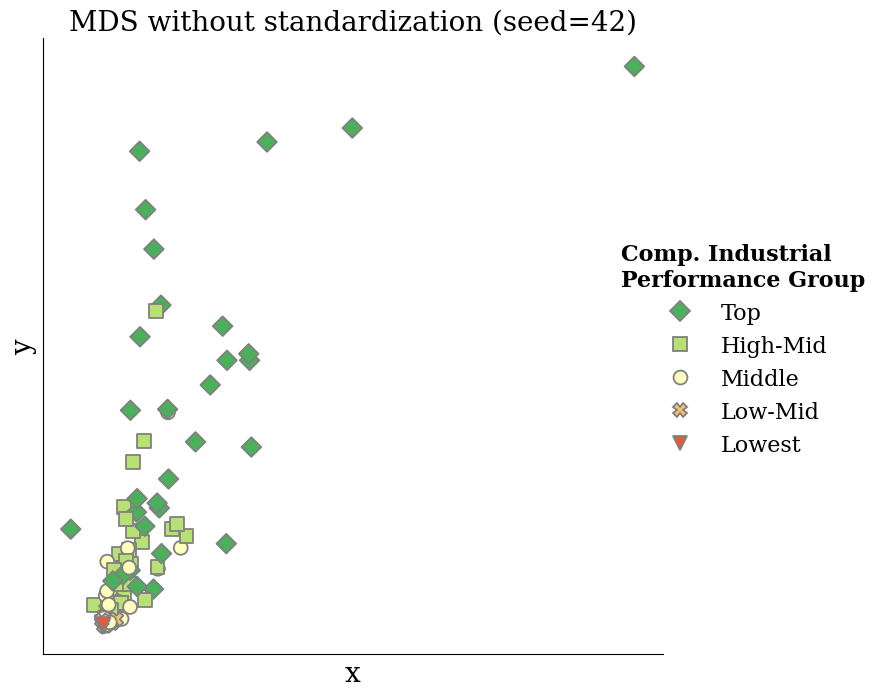

In [14]:
# MDS, two components, seed = 42, axis names ("x", "y")
mds_result = pd.DataFrame( 
    MDS(n_components=2, random_state=42).fit_transform(X),
    columns=["x", "y"] 
) 

mds_result["CIP Score"] = cip_scores # adds CIP score as third variable to the dataframe
mds_result["Country"] = countries # adds country names to 4th column

# Create quintiles accroding to CIP values
mds_result["CIP Group"] = pd.qcut(mds_result["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Plotting the MDS dataframe
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(mds_result,
                x="x",
                y="y",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=100,
                edgecolor="gray",
                linewidth=1.3)

# Legend formatting
ax.legend(bbox_to_anchor=(0.9, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Group",
          title_fontproperties={'weight': 'bold', 'size': 16})

# Figure plotting area formatting
plt.title('MDS without standardization (seed=42)')
sns.despine(fig)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/mds_seed_42.png", dpi=300, bbox_inches='tight')
plt.show()

### **MDS (Multidimensional scaling)** seed = 14

C:\Users\Lauri\OneDrive - Aalto University\Tiedostot\Koulujuttuja\2026 Information Visualization\infoviz\.venv\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


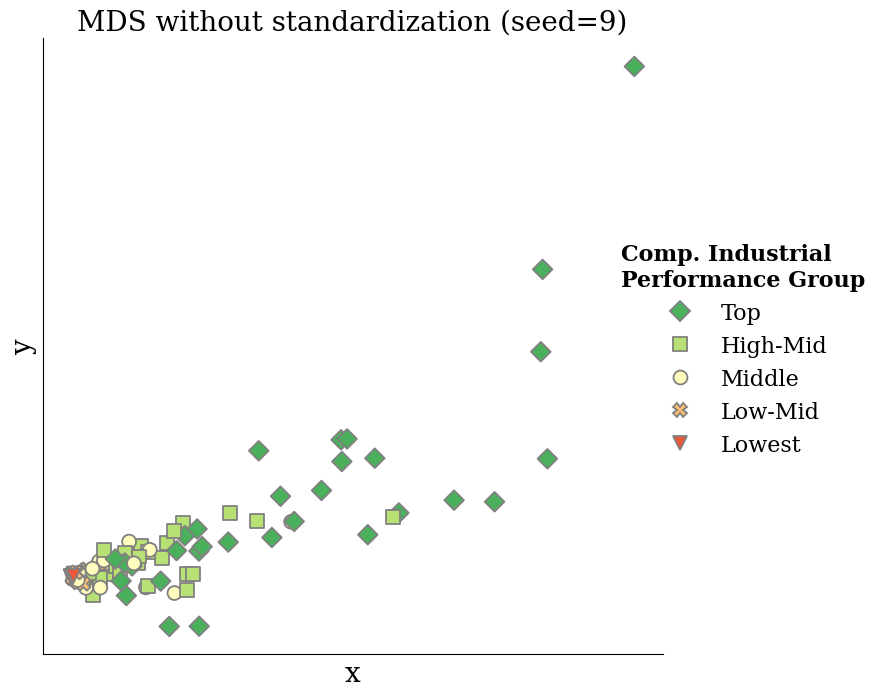

In [15]:
# MDS, two coomponents, seed = 9, axis names ("x", "y")
mds_result = pd.DataFrame( 
    MDS(n_components=2, random_state=14).fit_transform(X),
    columns=["x", "y"] 
) 

mds_result["CIP Score"] = cip_scores # adds CIP score as third variable to the dataframe
mds_result["Country"] = countries # adds country names to 4th column

# Create quintiles accroding to CIP values
mds_result["CIP Group"] = pd.qcut(mds_result["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Plotting the MDS dataframe
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(mds_result,
                x="x",
                y="y",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=100,
                edgecolor="gray",
                linewidth=1.3)

# Legend formatting
ax.legend(bbox_to_anchor=(0.9, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Group",
          title_fontproperties={'weight': 'bold', 'size': 16})

# Figure plotting area formatting
plt.title('MDS without standardization (seed=9)')
sns.despine(fig)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/mds_seed_9.png", dpi=300, bbox_inches='tight')
plt.show()

### **Last part of task 1, t-SNE** (t-distributed Stochastic Neighbor Embedding)

Non-standardized data, two different seeds and three different perplexity values for each seed. 6 figures in total.

**Seed = 42, perplexity = 9:**

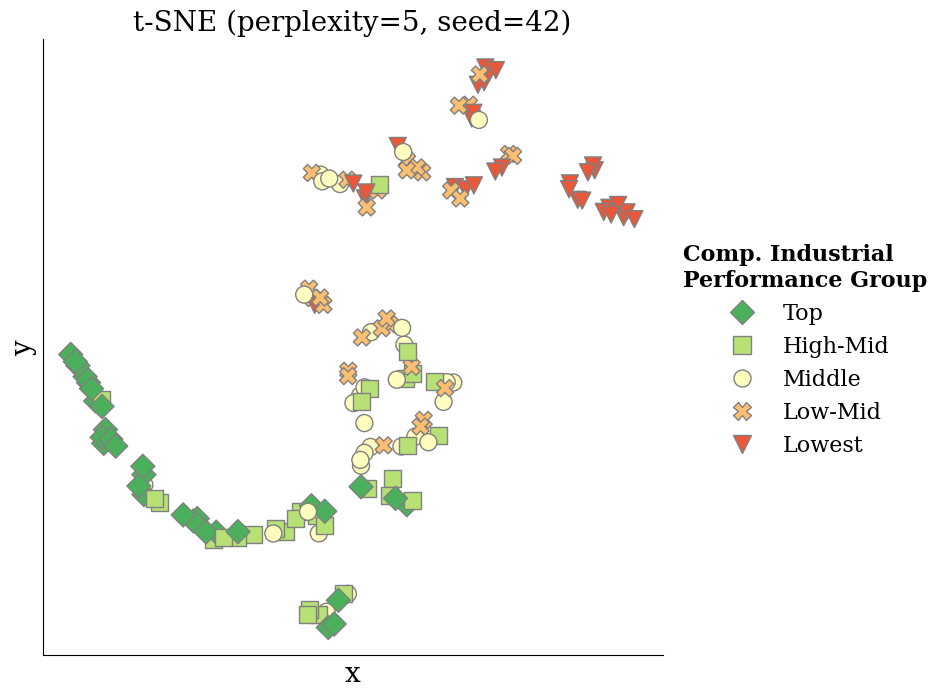

In [26]:
#t-SNE on non-standardized data — perplexity=5, seed=42
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=5, random_state=42, init="random").fit_transform(X),
    columns=["x", "y"]
)

tsne_result["CIP Score"] = cip_scores # cip scores as 3rd column to data frame
tsne_result["Country"] = countries # countries as 4th


# Create quintiles accroding to CIP values
tsne_result["CIP Group"] = pd.qcut(tsne_result["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=150,
                edgecolor="gray",
                linewidth=1)

# Legend formatting
ax.legend(bbox_to_anchor=(1, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Group",
          title_fontproperties={'weight': 'bold', 'size': 16})

# Plot area formatting
plt.title('t-SNE (perplexity=5, seed=42)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/tsne_perp5_seed42.png", dpi=300, bbox_inches='tight')
plt.show()

**Seed = 42, perplexity = 18:**

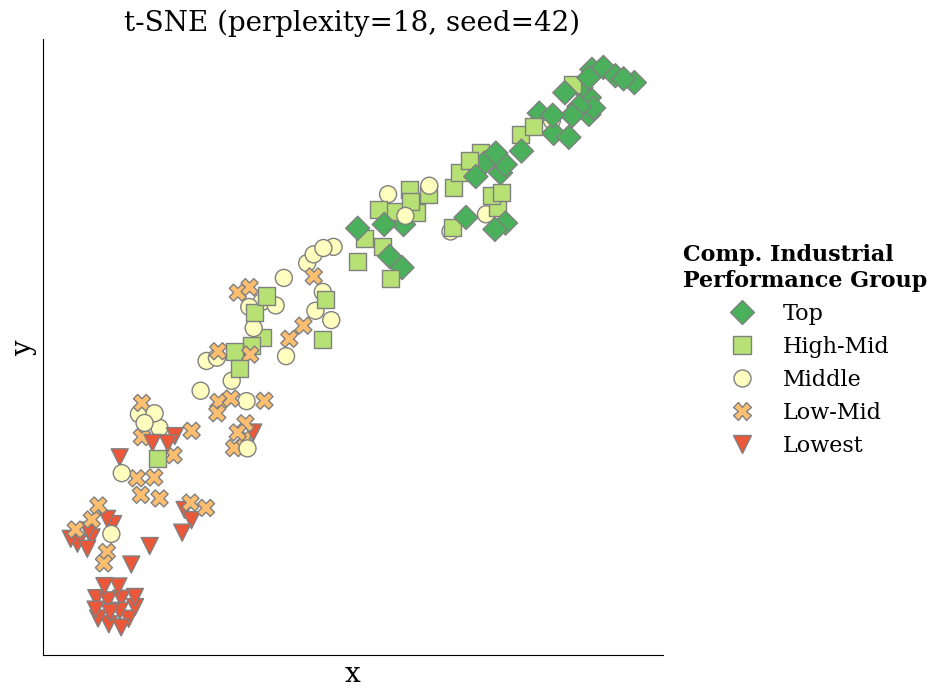

In [24]:
#t-SNE on non-standardized data — perplexity=18, seed=42
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=18, random_state=42, init="random").fit_transform(X),
    columns=["x", "y"]
)

tsne_result["CIP Score"] = cip_scores # cip scores as 3rd column to data frame
tsne_result["Country"] = countries # countries as 4th


# Create quintiles accroding to CIP values
tsne_result["CIP Group"] = pd.qcut(tsne_result["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=150,
                edgecolor="gray",
                linewidth=1)

# Legend formatting
ax.legend(bbox_to_anchor=(1, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Group",
          title_fontproperties={'weight': 'bold', 'size': 16})

# Plot area formatting
plt.title('t-SNE (perplexity=18, seed=42)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/tsne_perp18_seed42.png", dpi=300, bbox_inches='tight')
plt.show()

**Seed = 42, perplexity = 91:**

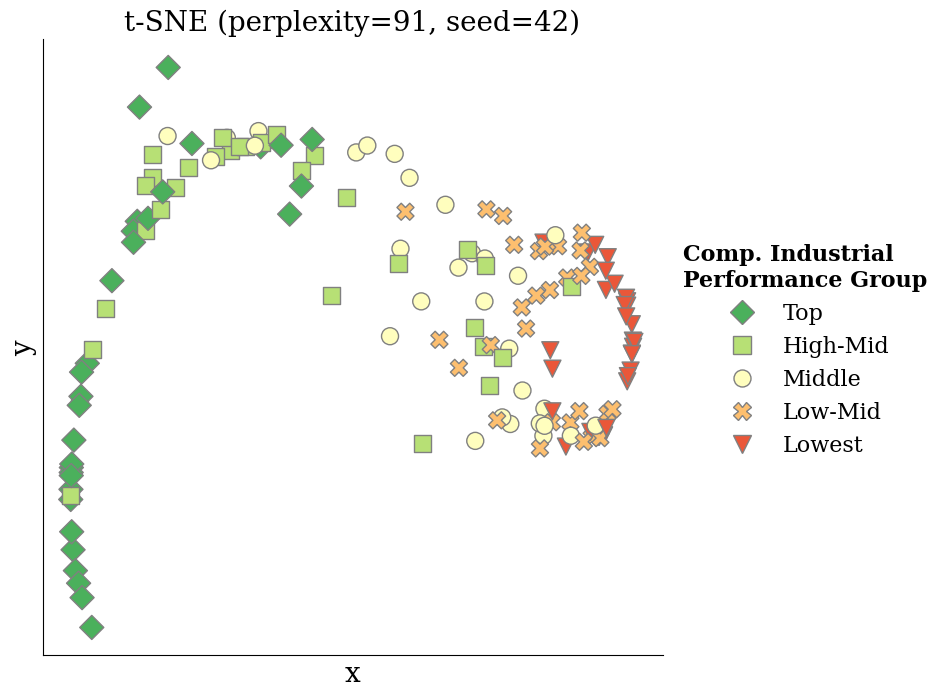

In [25]:
#t-SNE on non-standardized data — perplexity=91, seed=42
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=91, random_state=42, init="random").fit_transform(X),
    columns=["x", "y"]
)

tsne_result["CIP Score"] = cip_scores # cip scores as 3rd column to data frame
tsne_result["Country"] = countries # countries as 4th


# Create quintiles accroding to CIP values
tsne_result["CIP Group"] = pd.qcut(tsne_result["CIP Score"], q=5, labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Top"])

# Order groups from highest to lowest and assign different markers for the groups
group_order = ["Top", "High-Mid", "Middle", "Low-Mid", "Lowest"]
markers = {"Top": "D", "High-Mid": "s", "Middle": "o", "Low-Mid": "X", "Lowest": "v"} #markers for data points

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="CIP Group",
                style="CIP Group",
                hue_order=group_order,
                style_order=group_order,
                markers=markers,
                palette="RdYlGn_r",
                s=150,
                edgecolor="gray",
                linewidth=1)

# Legend formatting
ax.legend(bbox_to_anchor=(1, 0.7),
          loc='upper left',
          fontsize=16,
          title="Comp. Industrial\nPerformance Group",
          title_fontproperties={'weight': 'bold', 'size': 16})

# Plot area formatting
plt.title('t-SNE (perplexity=91, seed=42)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/tsne_perp61_seed42.png", dpi=300, bbox_inches='tight')
plt.show()

### Then, seed 14, t-SNE

In the last three visualizations, I am mapping countries by continent instead of mappind them by CIP group. 

**Grouping continents into different categories:**

In [20]:
# Continent mapping
continent_map = {
    # Africa
    "Algeria": "Africa", "Angola": "Africa", "Botswana": "Africa", "Burundi": "Africa",
    "Cabo Verde": "Africa", "Cameroon": "Africa", "Central African Republic": "Africa",
    "Congo": "Africa", "Côte d'Ivoire": "Africa", "Egypt": "Africa", "Eritrea": "Africa",
    "Eswatini": "Africa", "Ethiopia": "Africa", "Gabon": "Africa", "Gambia": "Africa",
    "Ghana": "Africa", "Kenya": "Africa", "Madagascar": "Africa", "Malawi": "Africa",
    "Mauritius": "Africa", "Morocco": "Africa", "Mozambique": "Africa", "Namibia": "Africa",
    "Niger": "Africa", "Nigeria": "Africa", "Rwanda": "Africa", "Senegal": "Africa",
    "South Africa": "Africa", "Tunisia": "Africa", "Uganda": "Africa",
    "United Republic of Tanzania": "Africa", "Zambia": "Africa", "Zimbabwe": "Africa",
    # Asia
    "Afghanistan": "Asia", "Armenia": "Asia", "Azerbaijan": "Asia", "Bahrain": "Asia",
    "Bangladesh": "Asia", "Brunei Darussalam": "Asia", "Cambodia": "Asia", "China": "Asia",
    "China, Hong Kong SAR": "Asia", "China, Macao SAR": "Asia",
    "China, Taiwan Province": "Asia", "Georgia": "Asia", "India": "Asia",
    "Indonesia": "Asia", "Iran (Islamic Republic of)": "Asia", "Iraq": "Asia",
    "Israel": "Asia", "Japan": "Asia", "Jordan": "Asia", "Kazakhstan": "Asia",
    "Kuwait": "Asia", "Kyrgyzstan": "Asia", "Lao People's Democratic Republic": "Asia",
    "Lebanon": "Asia", "Malaysia": "Asia", "Maldives": "Asia", "Mongolia": "Asia",
    "Myanmar": "Asia", "Nepal": "Asia", "Oman": "Asia", "Pakistan": "Asia",
    "Philippines": "Asia", "Qatar": "Asia", "Republic of Korea": "Asia",
    "Saudi Arabia": "Asia", "Singapore": "Asia", "Sri Lanka": "Asia",
    "State of Palestine": "Asia", "Syrian Arab Republic": "Asia", "Tajikistan": "Asia",
    "Thailand": "Asia", "Türkiye": "Asia", "United Arab Emirates": "Asia",
    "Uzbekistan": "Asia", "Viet Nam": "Asia", "Yemen": "Asia",
    # Europe
    "Albania": "Europe", "Austria": "Europe", "Belarus": "Europe", "Belgium": "Europe",
    "Bosnia and Herzegovina": "Europe", "Bulgaria": "Europe", "Croatia": "Europe",
    "Cyprus": "Europe", "Czechia": "Europe", "Denmark": "Europe", "Estonia": "Europe",
    "Finland": "Europe", "France": "Europe", "Germany": "Europe", "Greece": "Europe",
    "Hungary": "Europe", "Iceland": "Europe", "Ireland": "Europe", "Italy": "Europe",
    "Latvia": "Europe", "Lithuania": "Europe", "Luxembourg": "Europe", "Malta": "Europe",
    "Montenegro": "Europe", "Netherlands (Kingdom of the)": "Europe",
    "North Macedonia": "Europe", "Norway": "Europe", "Poland": "Europe",
    "Portugal": "Europe", "Republic of Moldova": "Europe", "Romania": "Europe",
    "Russian Federation": "Europe", "Serbia": "Europe", "Slovakia": "Europe",
    "Slovenia": "Europe", "Spain": "Europe", "Sweden": "Europe", "Switzerland": "Europe",
    "Ukraine": "Europe", "United Kingdom": "Europe",
    # North America
    "Bahamas": "North America", "Barbados": "North America", "Belize": "North America",
    "Bermuda": "North America", "Canada": "North America", "Costa Rica": "North America",
    "Cuba": "North America", "El Salvador": "North America", "Guatemala": "North America",
    "Haiti": "North America", "Honduras": "North America", "Jamaica": "North America",
    "Mexico": "North America", "Nicaragua": "North America", "Panama": "North America",
    "Saint Lucia": "North America", "Trinidad and Tobago": "North America",
    "United States of America": "North America",
    # South America
    "Argentina": "South America", "Bolivia (Plurinational State of)": "South America",
    "Brazil": "South America", "Chile": "South America", "Colombia": "South America",
    "Ecuador": "South America", "Paraguay": "South America", "Peru": "South America",
    "Suriname": "South America", "Uruguay": "South America",
    "Venezuela (Bolivarian Republic of)": "South America",
    # Oceania
    "Australia": "Oceania", "Fiji": "Oceania", "New Zealand": "Oceania",
    "Papua New Guinea": "Oceania", "Tonga": "Oceania",
}

**t-SNE code, Seed = 9, Perplexity = 9:**

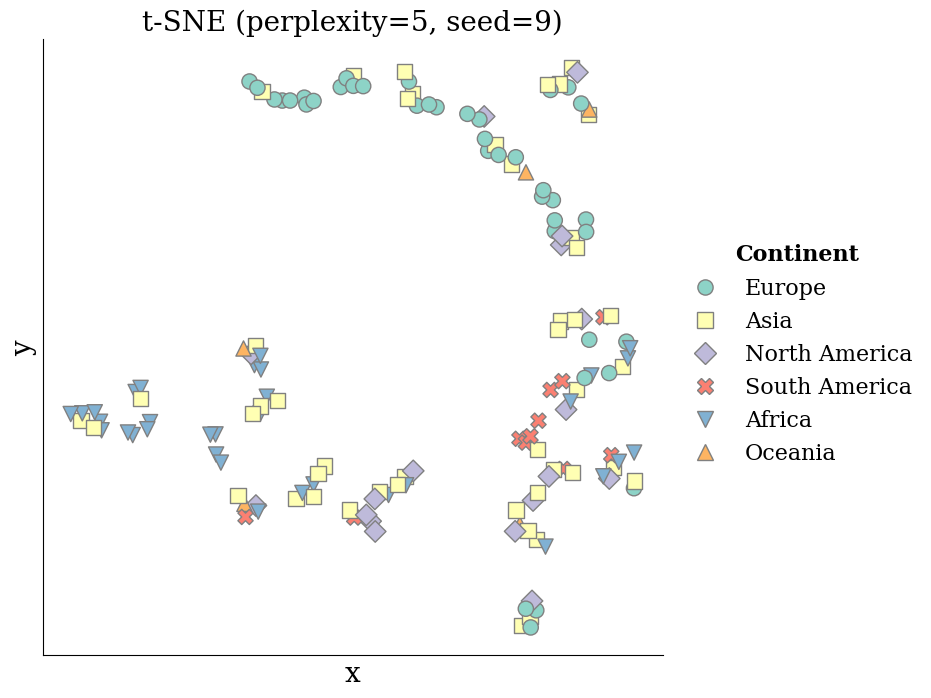

In [27]:
# t-SNE with continent grouping — perplexity=5, seed=9
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=5, random_state=9, init="random").fit_transform(X),
    columns=["x", "y"]
)

tsne_result["Country"] = countries
tsne_result["Continent"] = tsne_result["Country"].map(continent_map)

continent_order = ["Europe", "Asia", "North America", "South America", "Africa", "Oceania"]
continent_markers = {"Europe": "o", "Asia": "s", "North America": "D",
                     "South America": "X", "Africa": "v", "Oceania": "^"}

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="Continent",
                style="Continent",
                hue_order=continent_order,
                style_order=continent_order,
                markers=continent_markers,
                palette='Set3',
                s=120,
                edgecolor="gray",
                linewidth=1)

ax.legend(bbox_to_anchor=(1, 0.7),
          loc='upper left',
          fontsize=16,
          title="Continent",
          title_fontproperties={'weight': 'bold', 'size': 16})

plt.title('t-SNE (perplexity=5, seed=9)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../figures/tsne_perp5_seed9_continents.png", dpi=300, bbox_inches='tight')
plt.show()

**t-SNE code, Seed = 9, Perplexity = 18:**

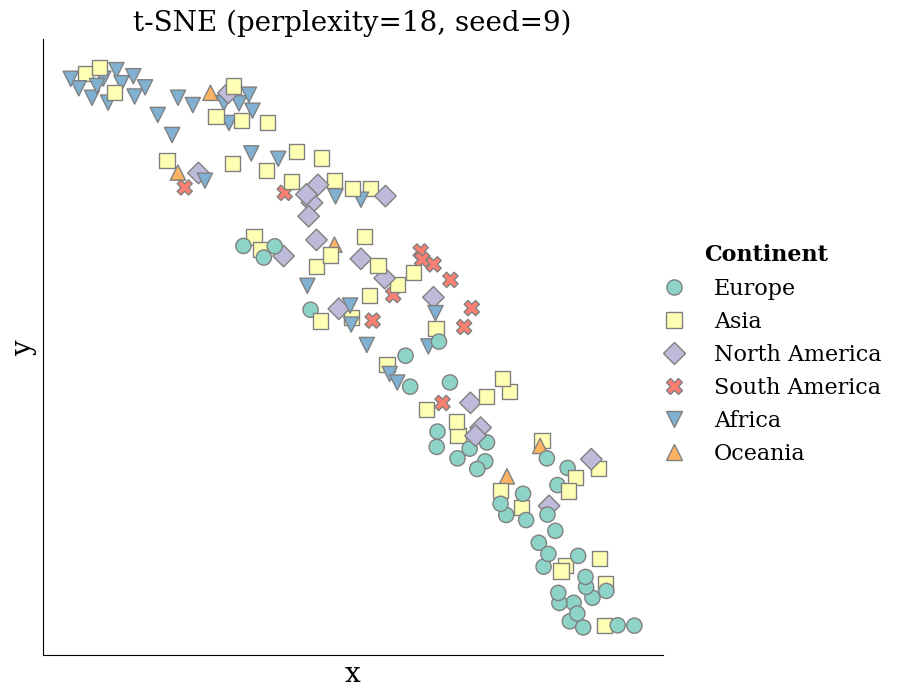

In [29]:
# t-SNE with continent grouping — perplexity=28, seed=9
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=18, random_state=9, init="pca").fit_transform(X),
    columns=["x", "y"]
)
tsne_result["Country"] = countries
tsne_result["Continent"] = tsne_result["Country"].map(continent_map)

continent_order = ["Europe", "Asia", "North America", "South America", "Africa", "Oceania"]
continent_markers = {"Europe": "o", "Asia": "s", "North America": "D",
                     "South America": "X", "Africa": "v", "Oceania": "^"}

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="Continent",
                style="Continent",
                hue_order=continent_order,
                style_order=continent_order,
                markers=continent_markers,
                palette='Set3',
                s=120,
                edgecolor="gray",
                linewidth=1)

ax.legend(bbox_to_anchor=(0.95, 0.7),
          loc='upper left',
          fontsize=16,
          title="Continent",
          title_fontproperties={'weight': 'bold', 'size': 16})

plt.title('t-SNE (perplexity=18, seed=9)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])

plt.savefig("../figures/tsne_perp18_seed9_continents.png", dpi=300, bbox_inches='tight')
plt.show()

**t-SNE code, Seed = 9, Perplexity = 91:**

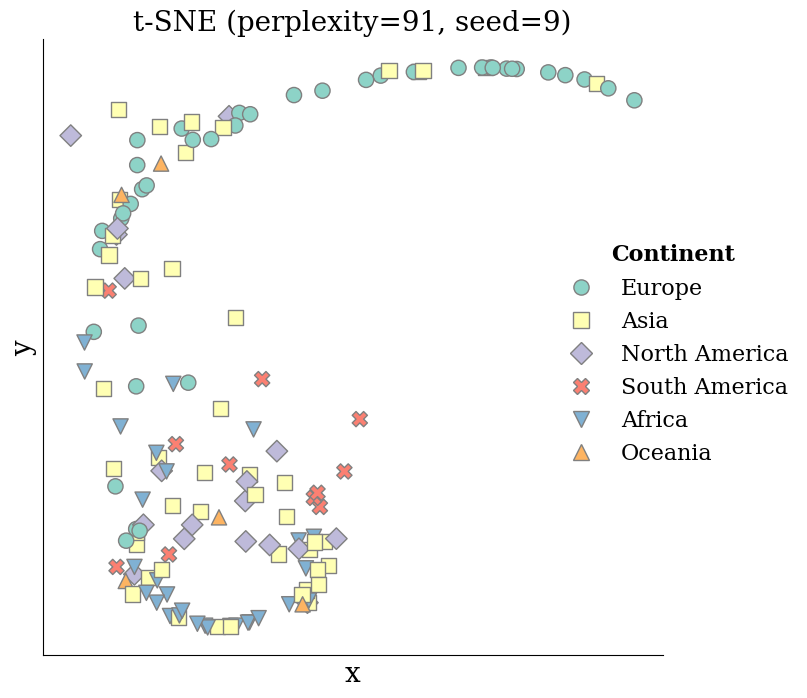

In [32]:
# t-SNE with continent grouping — perplexity=91, seed=9
tsne_result = pd.DataFrame(
    TSNE(n_components=2, perplexity=91, random_state=9, init="random").fit_transform(X),
    columns=["x", "y"]
)
tsne_result["Country"] = countries
tsne_result["Continent"] = tsne_result["Country"].map(continent_map)

continent_order = ["Europe", "Asia", "North America", "South America", "Africa", "Oceania"]
continent_markers = {"Europe": "o", "Asia": "s", "North America": "D",
                     "South America": "X", "Africa": "v", "Oceania": "^"}

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(tsne_result,
                x="x",
                y="y",
                hue="Continent",
                style="Continent",
                hue_order=continent_order,
                style_order=continent_order,
                markers=continent_markers,
                palette='Set3',
                s=120,
                edgecolor="gray",
                linewidth=1)

ax.legend(bbox_to_anchor=(0.80, 0.7),
          loc='upper left',
          fontsize=16,
          title="Continent",
          title_fontproperties={'weight': 'bold', 'size': 16})

plt.title('t-SNE (perplexity=91, seed=9)')
sns.despine(fig)
#ax.set_xlim(tsne_result["x"].min() - 5, tsne_result["x"].max() + 1)
#ax.set_ylim(tsne_result["y"].min() - 5, tsne_result["y"].max() + 1)
#ax.tick_params(axis='y', labelsize=20)
#ax.tick_params(axis='x', labelsize=20)
ax.set_xticklabels([]) # no numbers on x-axis
ax.set_yticklabels([]) # no numbers on y-axis
ax.set_xticks([])
ax.set_yticks([])

plt.savefig("../figures/tsne_perp61_seed9_continents.png", dpi=300, bbox_inches='tight')
plt.show()

# **Task 2:** Relational Data

**Creating and visualizing a network dataset that records the interconnections between sustainable development goals.**

Reading the created dataset: 

In [29]:
# Network data, 44 edges
edges = pd.read_csv("../data/network_data.csv")

Creating network dataset with networkx-library:

In [30]:
# Create the network
G = nx.from_pandas_edgelist(edges, source='node1', target='node2')
print(G)

Graph with 17 nodes and 44 edges


## Radial layout with numerical node ordering

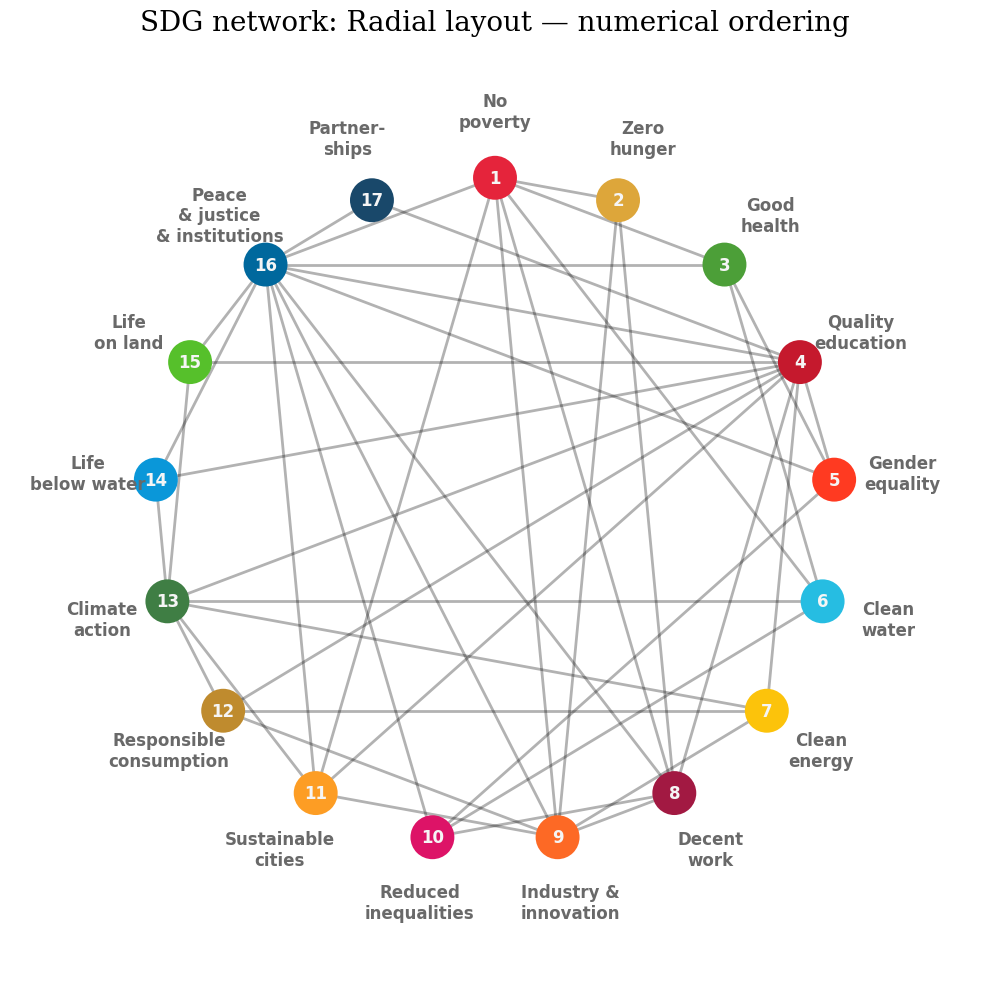

In [36]:
# SDG labels to show on graph
''' sdg_labels = {
    1: "1: No\npoverty",
    2: "2:\nZero\nhunger",
    3: "3:\nGood\nhealth",
    4: "4:\nQuality\neducation",
    5: "5:\nGender\nequality",
    6: "6:\nClean\nwater",
    7: "7:\nClean\nenergy",
    8: "8:\nDecent\nwork",
    9: "9:\nIndustry &\ninnovation",
    10: "10:\nReduced\ninequalities",
    11: "11:\nSustainable\ncities",
    12: "12:\nResponsible\nconsumption",
    13: "13:\nClimate\naction",
    14: "14: Life\nbelow water",
    15: "15:\nLife\non land",
    16: "16:\nPeace\n& justice",
    17: "17:\nPartner-\nships" '''

sdg_labels = {
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
    10: "10",
    11: "11",
    12: "12",
    13: "13",
    14: "14",
    15: "15",
    16: "16",
    17: "17" 
}

sdg_names = {
    1: "No\npoverty",
    2: "Zero\nhunger",
    3: "Good\nhealth",
    4: "Quality\neducation",
    5: "Gender\nequality",
    6: "Clean\nwater",
    7: "Clean\nenergy",
    8: "Decent\nwork",
    9: "Industry &\ninnovation",
    10: "Reduced\ninequalities",
    11: "Sustainable\ncities",
    12: "Responsible\nconsumption",
    13: "Climate\naction",
    14: "Life\nbelow water",
    15: "Life\non land",
    16: "Peace\n& justice\n& institutions",
    17: "Partner-\nships"
}

# Circular layout with numerical ordering
G_sorted = nx.Graph() #creates empty network graph object
G_sorted.add_nodes_from(range(1, 18)) # adds nodes 1 through 17 in order
G_sorted.add_edges_from(G.edges()) # copies the edges specified in 'edges' (network data)

# Starts node 1 from the top of the circle and continues clockwise
import math
pos = {}
for i, node in enumerate(G_sorted.nodes()):
    angle = math.pi/2 - (2 * math.pi * i / 17)
    pos[node] = (math.cos(angle), math.sin(angle))


# color for each goal
sdg_colors = {
    1: '#E5243B',   # red
    2: '#DDA63A',   # mustard
    3: '#4C9F38',   # green
    4: '#C5192D',   # dark red
    5: '#FF3A21',   # orange-red
    6: '#26BDE2',   # light blue
    7: '#FCC30B',   # yellow
    8: '#A21942',   # burgundy
    9: '#FD6925',   # orange
    10: '#DD1367',  # magenta
    11: '#FD9D24',  # amber
    12: '#BF8B2E',  # dark gold
    13: '#3F7E44',  # dark green
    14: '#0A97D9',  # blue
    15: '#56C02B',  # bright green
    16: '#00689D',  # navy
    17: '#19486A',  # dark navy
}

node_colors = [sdg_colors[n] for n in G_sorted.nodes()]

# Plot figure and adjust its elements
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nx.draw_networkx_edges(G_sorted, pos, ax=ax, edge_color='black', alpha=0.3, width=2)
nx.draw_networkx_nodes(G_sorted, pos, ax=ax, node_size=1000, node_color=node_colors,
                       edgecolors='gray', linewidths=0)
nx.draw_networkx_labels(G_sorted, pos, labels=sdg_labels, ax=ax, font_size=12, font_weight='bold', font_color = 'whitesmoke')

# create "outer circle" from node names
label_pos = {k: (v[0] * 1.20, v[1] * 1.20) for k, v in pos.items()}
nx.draw_networkx_labels(G_sorted, label_pos, labels=sdg_names, ax=ax, font_size=12, font_weight='bold', font_color = 'dimgray')

ax.set_title('SDG network: Radial layout — numerical ordering', pad=-100)
ax.set_axis_off()
ax.margins(0.15)
plt.tight_layout()
plt.savefig("../figures/radial_layout.png", dpi=300, bbox_inches='tight')
plt.show()

## Kamada-Kawai

Networkx package only produces deterministic network plots. Seed needs to be assigned with workaround. 

**Seed = 42:**

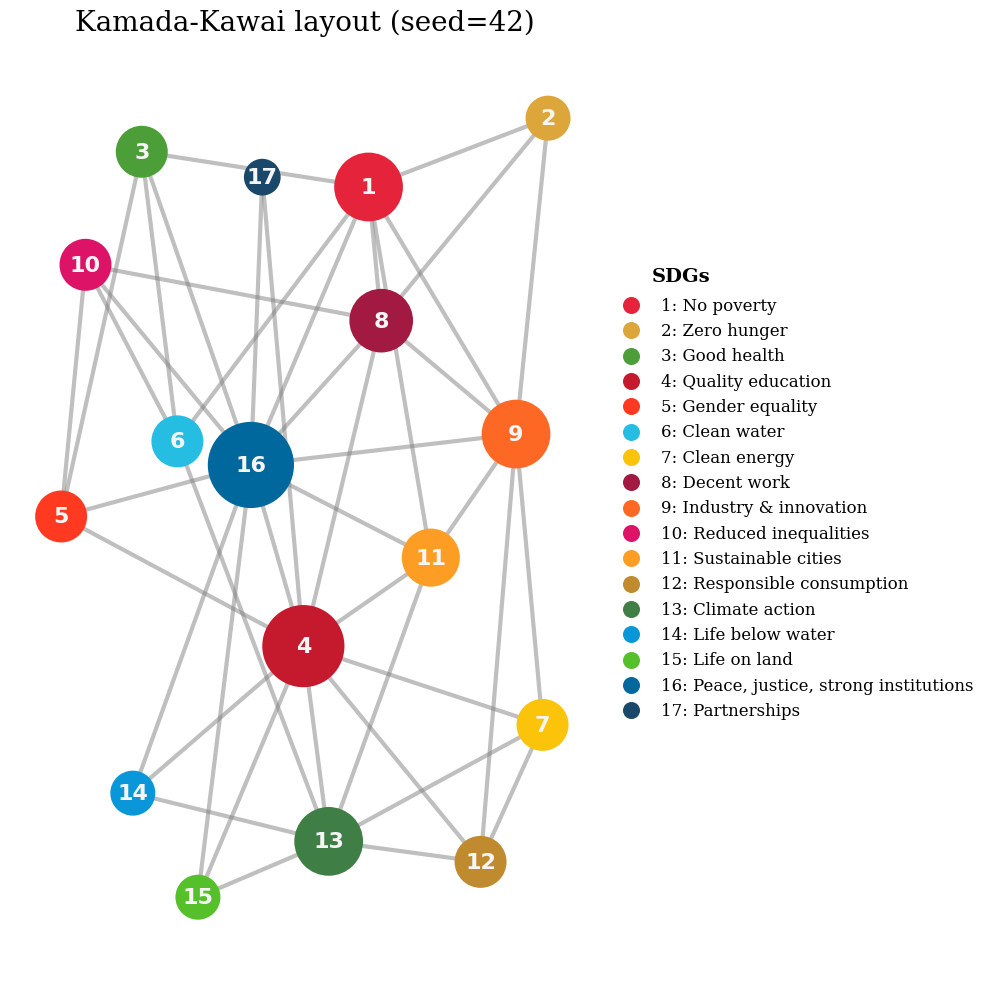

In [32]:
# Calculate degree (number of edges) for each node
degrees = dict(G_sorted.degree())
node_sizes = [degrees[n] * 350 for n in G_sorted.nodes()]

# Kamada-Kawai — seed 42
np.random.seed(42)
pos1_kk_start = nx.fruchterman_reingold_layout(G_sorted)
pos1_kk = nx.kamada_kawai_layout(G_sorted, pos=pos1_kk_start)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nx.draw_networkx_edges(G_sorted, pos1_kk, ax=ax, edge_color='gray', alpha=0.5, width=3)
nx.draw_networkx_nodes(G_sorted, pos1_kk, ax=ax, node_size=node_sizes, node_color=node_colors,
                       edgecolors='gray', linewidths=0)

#label_pos_kk = {k: (v[0], v[1] + 0.06) for k, v in pos_kk.items()}
nx.draw_networkx_labels(G_sorted, pos1_kk, labels=sdg_labels, ax=ax, font_size=16, font_weight='bold', font_color = 'whitesmoke')

# Legend
sdg_legend_labels = [
    "1: No poverty", "2: Zero hunger", "3: Good health",
    "4: Quality education", "5: Gender equality", "6: Clean water",
    "7: Clean energy", "8: Decent work", "9: Industry & innovation",
    "10: Reduced inequalities", "11: Sustainable cities",
    "12: Responsible consumption", "13: Climate action",
    "14: Life below water", "15: Life on land",
    "16: Peace, justice, strong institutions", "17: Partnerships"
]

#Legend dot modification
legend_handles = [plt.scatter([], [], c=sdg_colors[i+1], s=150, edgecolors='gray', linewidths=0)
                  for i in range(17)]

#Legend text modification
ax.legend(legend_handles, sdg_legend_labels,
          bbox_to_anchor=(1.00, 0.5),
          loc='center left',
          fontsize=12,
          frameon=False)

#Legend title modification
ax.annotate('SDGs', xy=(1.09, 0.74), xycoords='axes fraction',
            fontsize=14, fontweight='bold')

# Plot area formatting
ax.set_title('Kamada-Kawai layout (seed=42)', pad=0)
ax.set_axis_off()
ax.margins(0.05)
plt.tight_layout()
plt.savefig("../figures/kamada_kawai_seed42.png", dpi=300, bbox_inches='tight')
plt.show()

**Seed 9:**

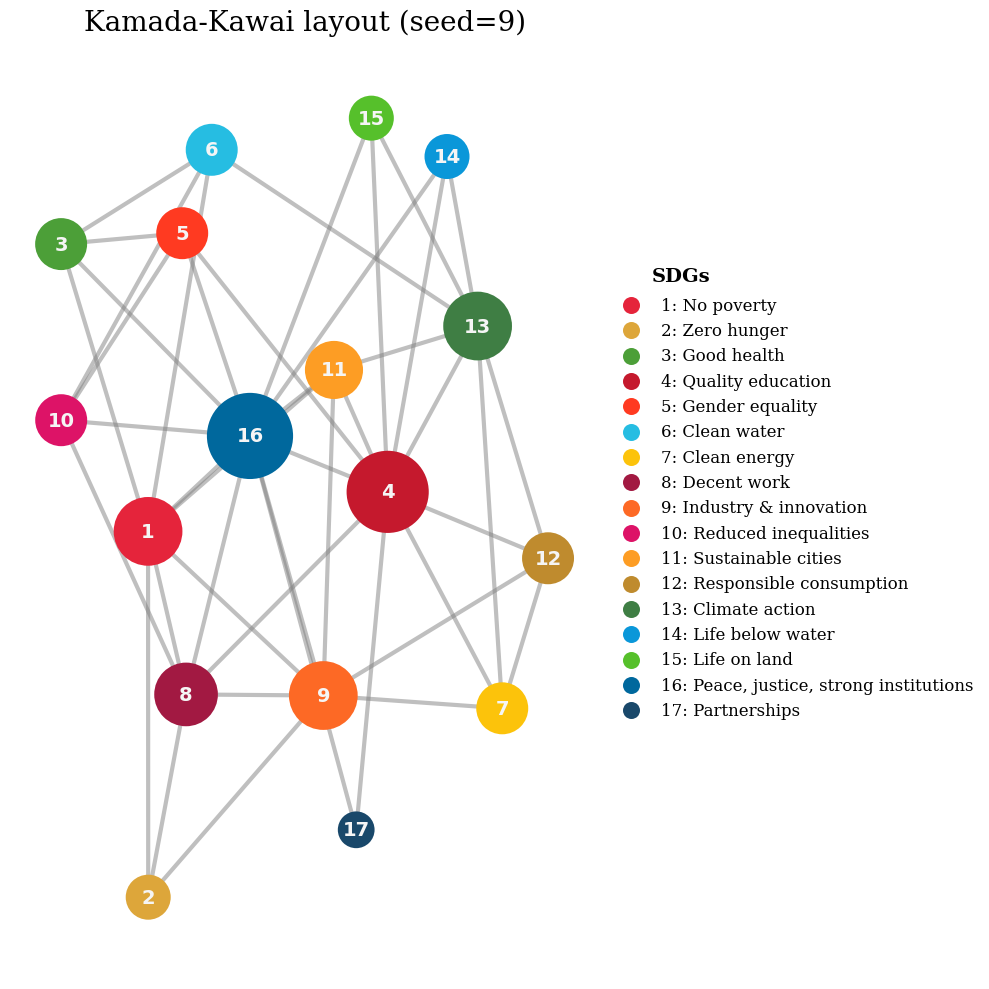

In [35]:
# Calculate degree (number of edges) for each node
degrees = dict(G_sorted.degree())
node_sizes = [degrees[n] * 350 for n in G_sorted.nodes()]

# Kamada-Kawai — seed 9
np.random.seed(9)
pos1_kk_start = nx.fruchterman_reingold_layout(G_sorted)
pos1_kk = nx.kamada_kawai_layout(G_sorted, pos=pos1_kk_start)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nx.draw_networkx_edges(G_sorted, pos1_kk, ax=ax, edge_color='gray', alpha=0.5, width=3)
nx.draw_networkx_nodes(G_sorted, pos1_kk, ax=ax, node_size=node_sizes, node_color=node_colors,
                       edgecolors='gray', linewidths=0)

#label_pos_kk = {k: (v[0], v[1] + 0.06) for k, v in pos_kk.items()}
nx.draw_networkx_labels(G_sorted, pos1_kk, labels=sdg_labels, ax=ax, font_size=14, font_weight='bold', font_color = 'whitesmoke')

# Legend
sdg_legend_labels = [
    "1: No poverty", "2: Zero hunger", "3: Good health",
    "4: Quality education", "5: Gender equality", "6: Clean water",
    "7: Clean energy", "8: Decent work", "9: Industry & innovation",
    "10: Reduced inequalities", "11: Sustainable cities",
    "12: Responsible consumption", "13: Climate action",
    "14: Life below water", "15: Life on land",
    "16: Peace, justice, strong institutions", "17: Partnerships"
]

#Legend dot modification
legend_handles = [plt.scatter([], [], c=sdg_colors[i+1], s=150, edgecolors='gray', linewidths=0)
                  for i in range(17)]

#Legend text modification
ax.legend(legend_handles, sdg_legend_labels,
          bbox_to_anchor=(1.00, 0.5),
          loc='center left',
          fontsize=12,
          frameon=False)

#Legend title modification
ax.annotate('SDGs', xy=(1.09, 0.74), xycoords='axes fraction',
            fontsize=14, fontweight='bold')

# Plot area formatting
ax.set_title('Kamada-Kawai layout (seed=9)', pad=0)
ax.set_axis_off()
ax.margins(0.05)
plt.tight_layout()
plt.savefig("../figures/kamada_kawai_seed9.png", dpi=300, bbox_inches='tight')
plt.show()

## Fruchterman-Reingold

Last visualizations. 

**Seed = 42:**

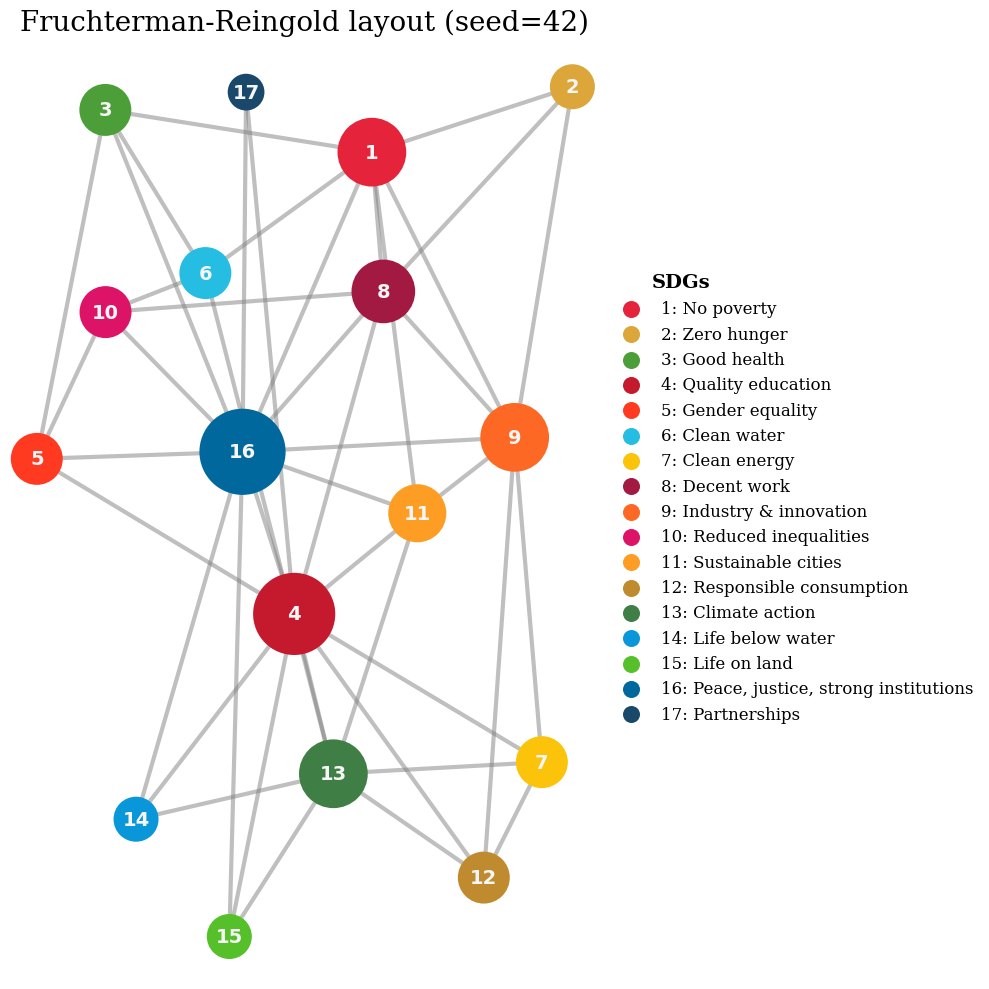

In [34]:
# Calculate degree (number of edges) for each node
degrees = dict(G_sorted.degree())
node_sizes = [degrees[n] * 350 for n in G_sorted.nodes()]

# Fruchterman-Reingold layout — seed 42
np.random.seed(42)
pos_fr1 = nx.fruchterman_reingold_layout(G_sorted)

# Figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nx.draw_networkx_edges(G_sorted, pos_fr1, ax=ax, edge_color='gray', alpha=0.5, width=3)
nx.draw_networkx_nodes(G_sorted, pos_fr1, ax=ax, node_size=node_sizes, node_color=node_colors,
                       edgecolors='gray', linewidths=0)
nx.draw_networkx_labels(G_sorted, pos_fr1, labels=sdg_labels, ax=ax, font_size=14,
                        font_weight='bold', font_color='whitesmoke')

# Legend
sdg_legend_labels = [
    "1: No poverty", "2: Zero hunger", "3: Good health",
    "4: Quality education", "5: Gender equality", "6: Clean water",
    "7: Clean energy", "8: Decent work", "9: Industry & innovation",
    "10: Reduced inequalities", "11: Sustainable cities",
    "12: Responsible consumption", "13: Climate action",
    "14: Life below water", "15: Life on land",
    "16: Peace, justice, strong institutions", "17: Partnerships"
]

#Legend dot modification
legend_handles = [plt.scatter([], [], c=sdg_colors[i+1], s=150, edgecolors='gray', linewidths=0)
                  for i in range(17)]

#Legend text modification
ax.legend(legend_handles, sdg_legend_labels,
          bbox_to_anchor=(1.00, 0.5),
          loc='center left',
          fontsize=12,
          frameon=False)

#Legend title modification
ax.annotate('SDGs', xy=(1.09, 0.74), xycoords='axes fraction',
            fontsize=14, fontweight='bold')

# Plot area
ax.set_title('Fruchterman-Reingold layout (seed=42)', pad=10)
ax.set_axis_off()
ax.margins(0.0)
plt.tight_layout()
plt.savefig("../figures/fruchterman_reingold_seed42.png", dpi=300, bbox_inches='tight')
plt.show()

**Seed = 9:**

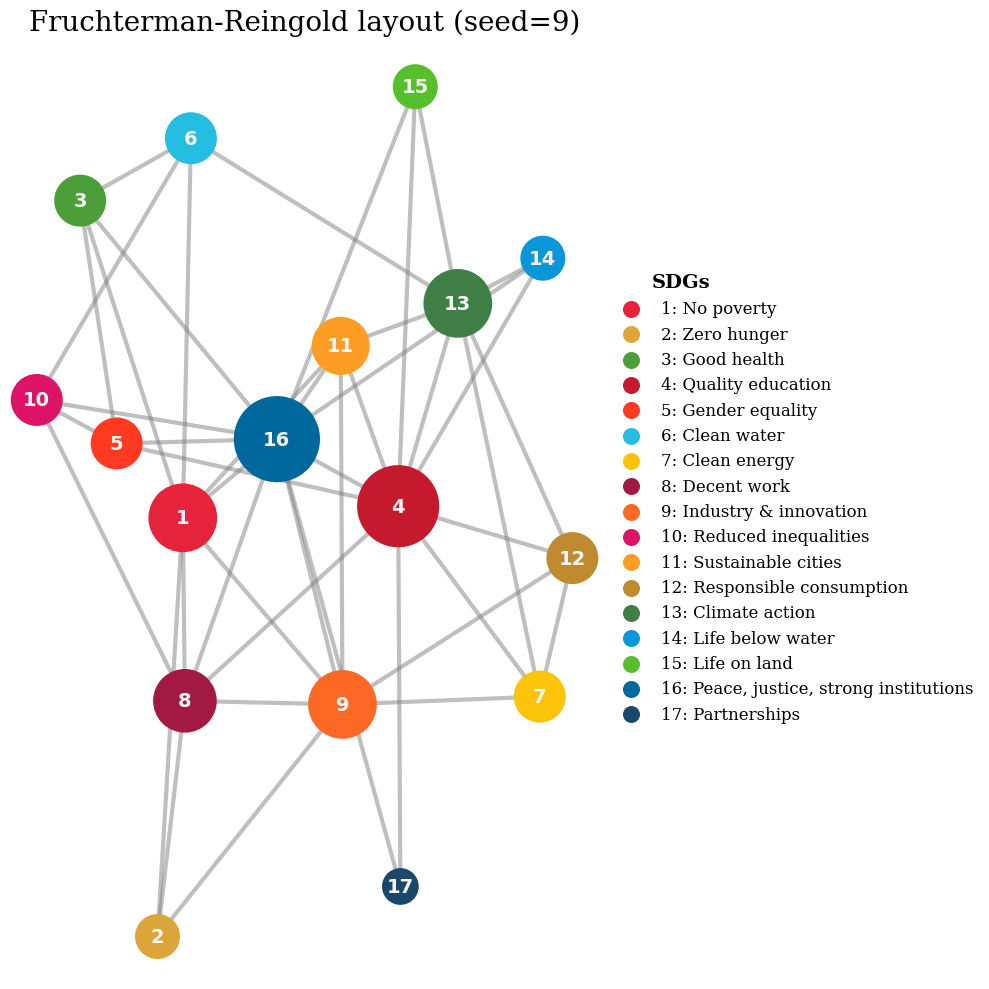

In [33]:
# Calculate degree (number of edges) for each node
degrees = dict(G_sorted.degree())
node_sizes = [degrees[n] * 350 for n in G_sorted.nodes()]

# Fruchterman-Reingold layout — seed 9
np.random.seed(9)
pos_fr2 = nx.fruchterman_reingold_layout(G_sorted)

# Figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nx.draw_networkx_edges(G_sorted, pos_fr2, ax=ax, edge_color='gray', alpha=0.5, width=3)
nx.draw_networkx_nodes(G_sorted, pos_fr2, ax=ax, node_size=node_sizes, node_color=node_colors,
                       edgecolors='gray', linewidths=0)
nx.draw_networkx_labels(G_sorted, pos_fr2, labels=sdg_labels, ax=ax, font_size=14,
                        font_weight='bold', font_color='whitesmoke')

# Legend
sdg_legend_labels = [
    "1: No poverty", "2: Zero hunger", "3: Good health",
    "4: Quality education", "5: Gender equality", "6: Clean water",
    "7: Clean energy", "8: Decent work", "9: Industry & innovation",
    "10: Reduced inequalities", "11: Sustainable cities",
    "12: Responsible consumption", "13: Climate action",
    "14: Life below water", "15: Life on land",
    "16: Peace, justice, strong institutions", "17: Partnerships"
]

#Legend dot modification
legend_handles = [plt.scatter([], [], c=sdg_colors[i+1], s=150, edgecolors='gray', linewidths=0)
                  for i in range(17)]

#Legend text modification
ax.legend(legend_handles, sdg_legend_labels,
          bbox_to_anchor=(1.00, 0.5),
          loc='center left',
          fontsize=12,
          frameon=False)

#Legend title modification
ax.annotate('SDGs', xy=(1.09, 0.74), xycoords='axes fraction',
            fontsize=14, fontweight='bold')

ax.set_title('Fruchterman-Reingold layout (seed=9)', pad=10)
ax.set_axis_off()
ax.margins(0.0)
plt.tight_layout()
plt.savefig("../figures/fruchterman_reingold_seed9.png", dpi=300, bbox_inches='tight')
plt.show()